In [140]:
import  pandas  as pd
import numpy as np
from data_preparation import df
import  matplotlib.pyplot as plt
import seaborn as sns
import random

In [141]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())

    print("*************")

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48
*************
model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914
*************
year
[2011 2012 2013 1992 1993]
28
*************
engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10
*************
engine_hp
[335. 300. 230. 320. 172.]
356
*************
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
*************
transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5
*************
driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4
*************
number_of_doors
[ 2.  4.  3. nan]
3
*************
market_category
<StringArra

<Axes: xlabel='msrp', ylabel='Count'>

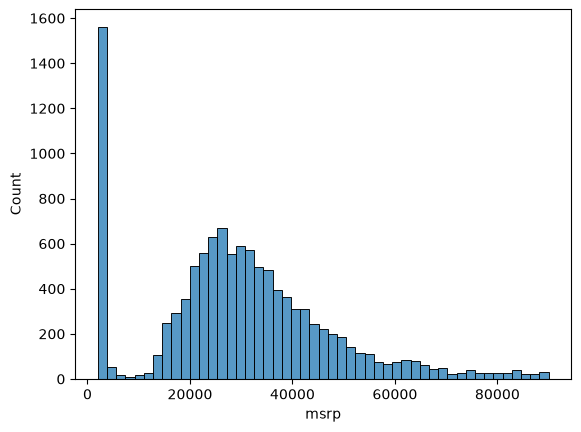

In [142]:
sns.histplot(df.msrp[df.msrp  < 90000], bins=49)


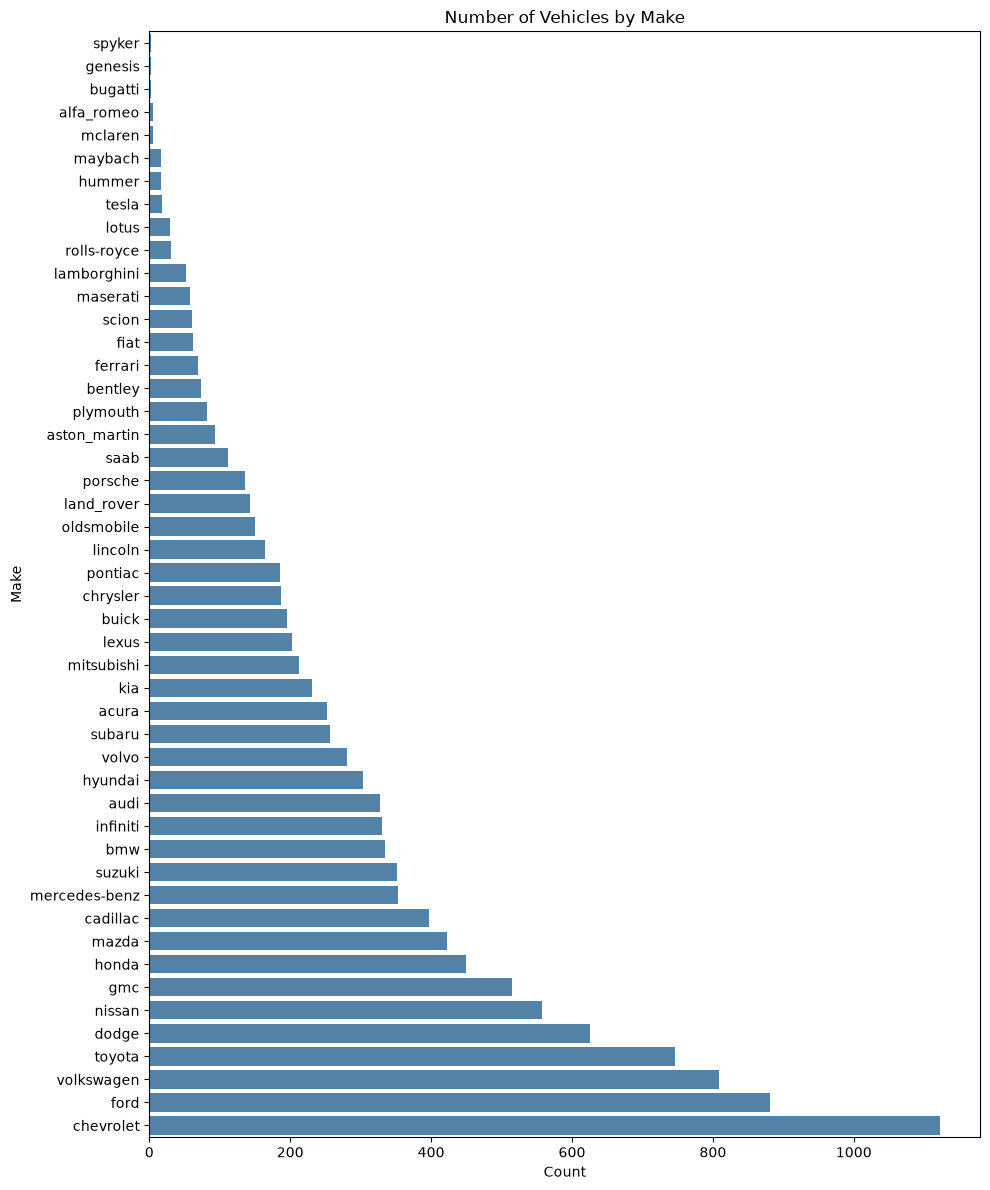

In [143]:
make_counts = df["make"].value_counts().sort_values()

plt.figure(figsize=(10, 12))
sns.barplot(x=make_counts.values, y=make_counts.index, color="steelblue")

plt.xlabel("Count")
plt.ylabel("Make")
plt.title("Number of Vehicles by Make")
plt.tight_layout()
plt.show()

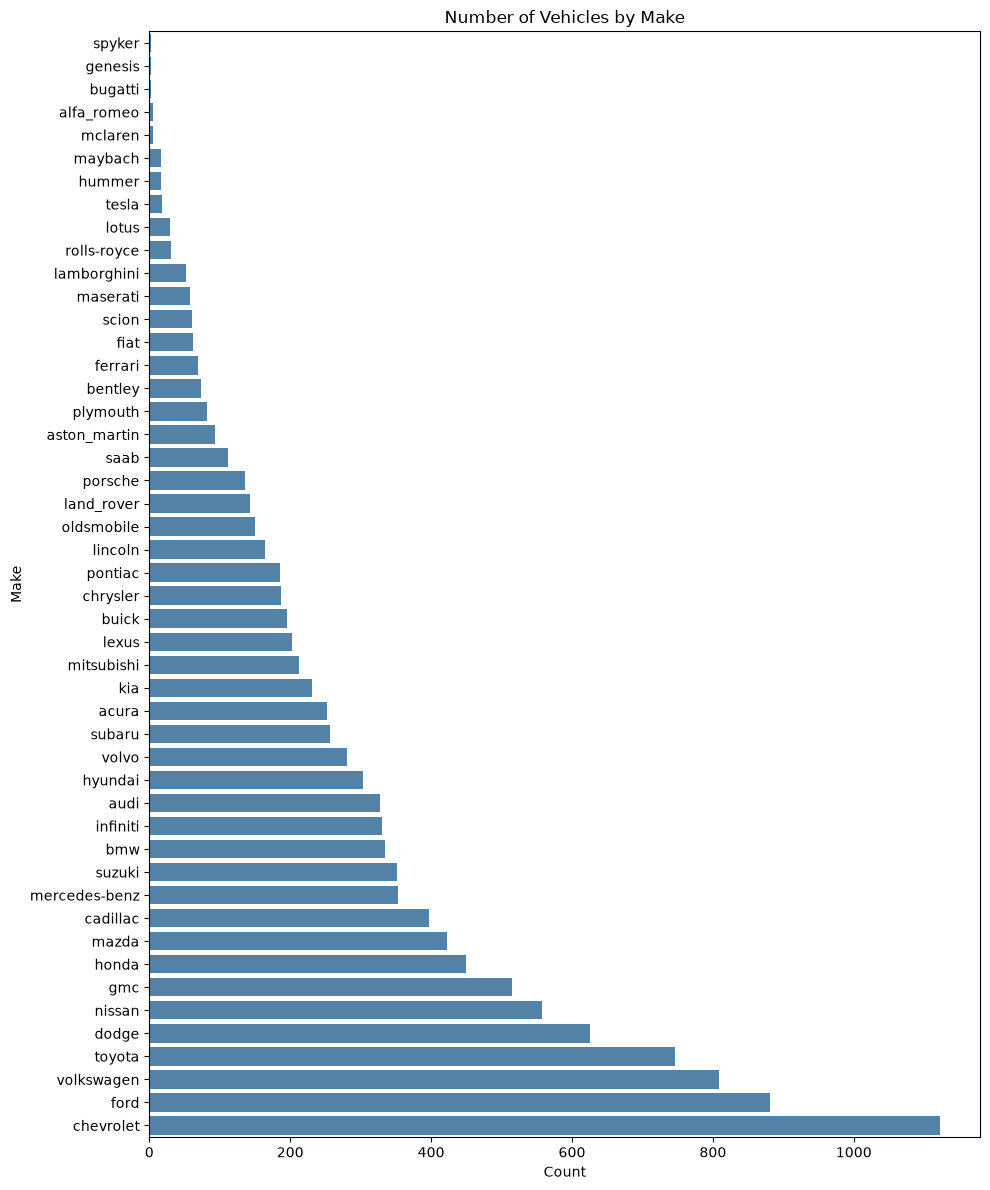

In [144]:
make_counts = df["make"].value_counts().sort_values()

plt.figure(figsize=(10, 12))
sns.barplot(x=make_counts.values, y=make_counts.index, color="steelblue")

plt.xlabel("Count")
plt.ylabel("Make")
plt.title("Number of Vehicles by Make")
plt.tight_layout()
plt.show()

<Axes: xlabel='msrp', ylabel='Count'>

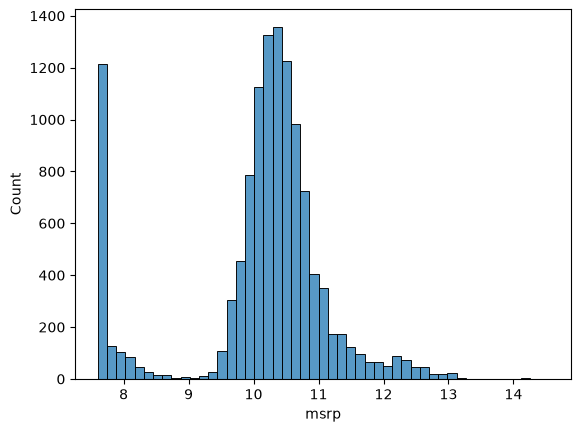

In [145]:
log_prices=np.log1p(df['msrp'])

sns.histplot(log_prices, bins=49)


we see a normal  disctribution

In [146]:
n=len(df)
n_valid=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_test-n_valid

print(f"({n_test},{n_train}, {n_valid})")

(2382,7150, 2382)


In [147]:
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_valid = df.iloc[idx[n_train:n_train+n_valid]]
df_test  = df.iloc[idx[n_train+n_valid:]]

In [148]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [149]:
df_valid=df_valid.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)
df_train=df_train.reset_index(drop=True)

In [150]:
y_train=np.array(np.log1p(df_train['msrp']))
y_valid=np.array(np.log1p(df_valid['msrp']))
y_test=np.array(np.log1p(df_test['msrp']))


In [151]:
del df_train['msrp']
del df_valid['msrp']
del df_test["msrp"]


## Régression linéaire — méthode des moindres carrés (équation normale)

On cherche les poids $w$ tels que :

$$X w = y$$

Le système est généralement **surdéterminé** (plus d'équations que d'inconnues), donc il n'existe pas de solution exacte en général. On cherche donc le $w$ qui **minimise l'erreur** $\|Xw - y\|^2$.

**Étape 1 — On multiplie à gauche par $X^T$ :**

$$X^T X w = X^T y$$

**Étape 2 — On inverse $X^TX$ (si elle est inversible) :**

$$w = (X^T X)^{-1} X^T y$$

C'est l'**équation normale**. Elle nous donne directement la solution optimale au sens des moindres carrés.

Dans le code ci-dessous :
- `X` est d'abord augmenté d'une colonne de 1 (pour estimer le biais $w_0$, c'est-à-dire l'ordonnée à l'origine)
- `XTX = XᵀX`
- `XTX_inv = (XᵀX)⁻¹`
- `w = (XᵀX)⁻¹ Xᵀy`

Le premier élément de `w` est le biais (intercept), les suivants sont les coefficients associés à chaque variable de `X`.

In [152]:
def train_linear_regression(X,y):
    X=np.column_stack((np.ones(X.shape[0]),X))
    XTX=np.dot(X.T,X)
    XTX_inv=np.linalg.inv(XTX)
    w=np.dot(XTX_inv,np.dot(X.T,y))
    return w[0], w[1:]

In [153]:
df_test.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [154]:
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']
df_train=df_train.fillna(0)
X_train=df_train[base].values

In [155]:
w0, w = train_linear_regression(X_train,y_train)
print(w0, w)

7.927257388069929 [ 9.70589522e-03 -1.59103494e-01  1.43792133e-02  1.49441072e-02
 -9.06908672e-06]


In [156]:
predictions=w0+X_train@w
print(np.expm1(predictions[:5]))

[14014.62180872 11935.30375066 15865.69570384  5734.25918817
 52365.39545412]


<Axes: ylabel='Count'>

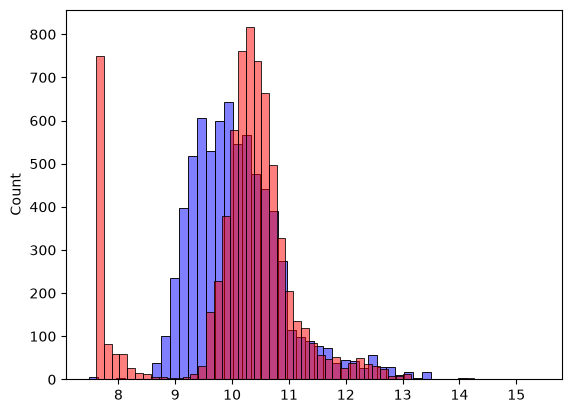

In [157]:
sns.histplot(predictions, bins=50, color="blue" ,alpha=0.5)
sns.histplot(y_train, bins=50, color="red", alpha=0.5)

c'est une méthode efficace pour résoudre les problèmes de régression linéaire, surtout lorsque le nombre de variables est relativement petit. Cependant, pour des ensembles de données très grands ou lorsque $X^TX$ est mal conditionné, d'autres méthodes comme la descente de gradient peuvent être préférables.

In [158]:
def rmse(y, y_pred):
    error=y-y_pred
    mse=(error**2).mean()
    return np.sqrt(mse)

In [159]:
rmse_train=rmse(y_train,predictions)
rmse_reel=rmse(np.expm1(y_train),np.expm1(predictions))
print(rmse_train)
print(rmse_reel)

0.7554192603920132
92070.4161495083


## RMSE (Root Mean Squared Error)

Le RMSE mesure l'écart moyen entre les valeurs prédites $\hat{y}_i$ et les valeurs réelles $y_i$. Sa formule est :

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

où $n$ est le nombre d'observations, $y_i$ la valeur réelle et $\hat{y}_i$ la valeur prédite.

On part du résidu, c'est-à-dire l'erreur commise sur chaque observation, $e_i = y_i - \hat{y}_i$. Cette erreur peut être positive ou négative selon que le modèle sous-estime ou surestime. Pour pouvoir les combiner sans qu'elles s'annulent entre elles, on les élève au carré, $e_i^2 = (y_i - \hat{y}_i)^2$. Ce carré a un effet important : une petite erreur reste petite, mais une grosse erreur est démesurément amplifiée, une erreur de 10 devient 100 alors qu'une erreur de 20 devient 400, soit quatre fois plus alors que l'erreur n'a fait que doubler. C'est ce qui rend le RMSE particulièrement sensible aux grosses erreurs et aux valeurs extrêmes.

On fait ensuite la moyenne de ces erreurs au carré sur toutes les observations, ce qui donne le MSE, $\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$. Le problème du MSE est qu'il est exprimé dans une unité au carré, des dollars au carré par exemple, ce qui n'a pas de sens concret. On prend donc sa racine carrée pour revenir à l'unité d'origine de $y$, et c'est ce qui donne le RMSE. Le RMSE est toujours positif ou nul, il vaut zéro uniquement si le modèle prédit parfaitement toutes les valeurs, et il est toujours exprimé dans la même unité que $y$.

### Interprétation de mes résultats

J'ai obtenu un RMSE de 0.755 sur `y_train` en log, et un RMSE de 92070 dollars après avoir repassé les valeurs en échelle réelle avec `expm1`. Ces deux chiffres mesurent la même erreur mais racontent des choses différentes.

Le RMSE en log, 0.755, mesure une erreur relative plutôt qu'absolue, puisque travailler sur le log transforme les rapports en différences. Cette valeur correspond à un facteur d'erreur multiplicatif d'environ $e^{0.755} \approx 2.13$, ce qui veut dire qu'en moyenne mes prédictions s'écartent d'un facteur 2 environ par rapport au vrai prix, dans un sens ou dans l'autre. C'est une erreur assez conséquente, qui montre qu'il reste de la marge pour améliorer le modèle.

Le RMSE en valeurs réelles, 92070 dollars, est beaucoup plus impressionnant en apparence, mais il faut le lire avec prudence. Comme le carré amplifie fortement les grosses erreurs, il suffit de quelques prédictions très mauvaises sur des véhicules très chers, supercars ou voitures de luxe, pour faire exploser cette métrique, même si la majorité de mes prédictions sur des véhicules ordinaires sont raisonnables. L'écart énorme entre les deux résultats, 0.755 en log contre 92070 en dollars, confirme d'ailleurs que la distribution des prix est très asymétrique, avec quelques valeurs extrêmes qui dominent l'erreur en échelle réelle. C'est justement pour cette raison que j'ai entraîné mon modèle sur `log1p(msrp)` plutôt que sur le prix brut, afin d'éviter que ces quelques véhicules très chers ne dominent complètement l'apprentissage.

In [160]:
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']

def prepare_X(df):
    df=df.copy()
    df['age']=2017-df.year
    df=df.fillna(0)
    features=base+['age']
    X=df[features].values
    return X

# train the model 
X_train=prepare_X(df_train)
X_valid=prepare_X(df_valid)
w0 , w = train_linear_regression(X_train,y_train)

y_pred_valid=w0+X_valid@w
rmse_valid=rmse(y_valid,y_pred_valid)
print(rmse_valid)

0.5172055461058329


<Axes: ylabel='Count'>

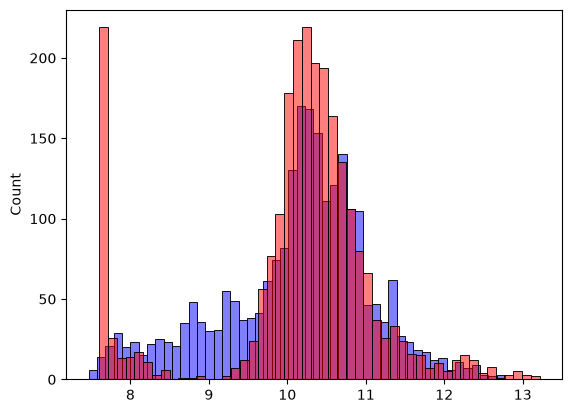

In [161]:
sns.histplot(y_pred_valid, bins=50, color="blue" ,alpha=0.5)
sns.histplot(y_valid, bins=50, color="red", alpha=0.5)

In [162]:
X_train

array([[1.480e+02, 4.000e+00, 3.300e+01, 2.400e+01, 1.385e+03, 9.000e+00],
       [1.320e+02, 4.000e+00, 3.200e+01, 2.500e+01, 2.031e+03, 5.000e+00],
       [1.480e+02, 4.000e+00, 3.700e+01, 2.800e+01, 6.400e+02, 1.000e+00],
       ...,
       [2.850e+02, 6.000e+00, 2.200e+01, 1.700e+01, 5.490e+02, 2.000e+00],
       [5.630e+02, 1.200e+01, 2.100e+01, 1.300e+01, 8.600e+01, 3.000e+00],
       [2.000e+02, 4.000e+00, 3.100e+01, 2.200e+01, 8.730e+02, 0.000e+00]],
      shape=(7150, 6))

In [163]:
df_train.number_of_doors.unique()

array([2., 4., 3., 0.])

In [164]:
def prepare_X(df):
    df=df.copy()
    features=base.copy()
    df['age']=2017-df.year
    features.append('age')
    for v  in [2,3,4]:
        df[f'number_of_doors_{v}']=(df.number_of_doors==v).astype(int)
        features.append(f'number_of_doors_{v}')
    df=df.fillna(0)
    X=df[features].values
    return X

In [165]:
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']
X_train=prepare_X(df_train)
w0 , w = train_linear_regression(X_train,y_train)
X_valid=prepare_X(df_valid)
predictions_valid=w0+X_valid@w
rmse_valid=rmse(y_valid,predictions_valid)
print(rmse_valid)

0.5157995641502041


In [166]:
list(df.make.value_counts().head().index)

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [167]:
def prepare_X(df):
    df=df.copy()
    features=base.copy()
    df['age']=2017-df.year
    features.append('age')
    for v  in [2,3,4]:
        df[f'number_of_doors_{v}']=(df.number_of_doors==v).astype(int)
        features.append(f'number_of_doors_{v}')
    for make in list(df.make.value_counts().head().index):
        df[f'make_{make}']=(df.make==make).astype(int)
        features.append(f'make_{make}')
    df=df.fillna(0)
    X=df[features].values
    return X

In [168]:
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']

X_train=prepare_X(df_train)
w0 , w = train_linear_regression(X_train,y_train)
X_valid=prepare_X(df_valid)
predictions_valid=w0+X_valid@w
rmse_valid=rmse(y_valid,predictions_valid)
print(rmse_valid)
print(rmse(np.expm1(y_valid),np.expm1(predictions_valid)))


0.5076038849557184
30210.217767361308


In [169]:
categories= ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']

categorical_features={cat: list(df_train[cat].value_counts().head().index) for cat in categories}


In [170]:
def prepare_X(df):
    df=df.copy()
    features=base.copy()
    df['age']=2017-df.year
    features.append('age')
    for v  in [2,3,4]:
        df[f'number_of_doors_{v}']=(df.number_of_doors==v).astype(int)
        features.append(f'number_of_doors_{v}')
    for cat, values in categorical_features.items():
        for v in values:
            df[f'{cat}_{v}']=(df[cat]==v).astype(int)
            features.append(f'{cat}_{v}')
    for make in list(df.make.value_counts().head().index):
        df[f'make_{make}']=(df.make==make).astype(int)
        features.append(f'make_{make}')
    df=df.fillna(0)
    X=df[features].values
    return X

base

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [171]:
def train_linear_regression_regulirizd(X,y,r=0.01):
    X=np.column_stack((np.ones(X.shape[0]),X))
    XTX=np.dot(X.T,X)+r*np.eye(X.shape[1])
    XTX_inv=np.linalg.inv(XTX)
    w=np.dot(XTX_inv,np.dot(X.T,y))
    return w[0], w[1:]

In [ ]:
X_train=prepare_X(pd.concat([df_train,df_valid]))
y_train=np.concatenate([y_train,y_valid])


0.4528867138531223


In [182]:
X_train

array([[148.,   4.,  33., ...,   0.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   1.,   0.],
       [148.,   4.,  37., ...,   0.,   0.,   0.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 46))

In [178]:
w0 , w = train_linear_regression_regulirizd(X_train,y_train,r=0.001)
X_test=prepare_X(df_test) 
y_test_pred=w0+X_test@w
rmse_test=rmse(y_test,y_test_pred)
print(rmse_test)

0.4528867138531223


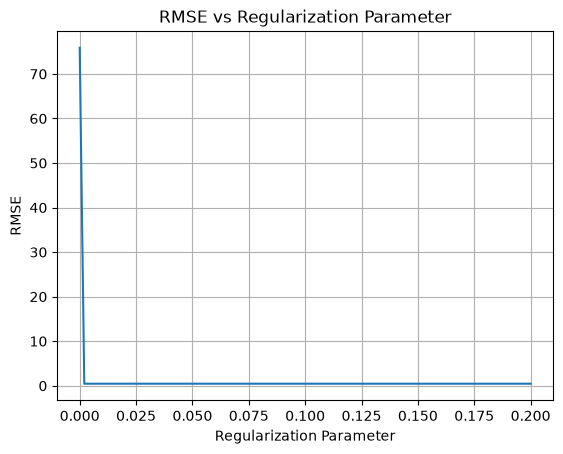

In [179]:
rmse_values=[]
xaxsix=np.linspace(0,0.2,100)
for i in xaxsix:
    w0 , w = train_linear_regression_regulirizd(X_train,y_train,r=i)
     
    y_test_pred=w0+X_test@w
    rmse_test=rmse(y_test,y_test_pred)
    rmse_values.append(rmse_test)

plt.plot(xaxsix,rmse_values)
plt.xlabel("Regularization Parameter")
plt.ylabel("RMSE")
plt.grid(True)
plt.title("RMSE vs Regularization Parameter")
plt.show()



In [180]:
min_rmse = min(rmse_values)
optimal_r = xaxsix[rmse_values.index(min_rmse)]
optimal_r, min_rmse

(np.float64(0.00202020202020202), np.float64(0.452887032975467))

In [181]:
print(np.expm1(y_test_pred))
print(np.expm1(y_test)-np.expm1(y_test_pred))


[ 4048.90218997 11869.97852039 29952.39586619 ... 15283.55260494
 23931.94824445 38267.33769946]
[-2048.90218997 -8658.97852039  1167.60413381 ... 13816.44739506
 -1731.94824445 -5272.33769946]
